<img src="Logo_UNSAM.png" width="180">

### Análisis y Procesamiento de Señales

# Trabajo Práctico N°4: Primeras nociones de estimación espectral.

### Paulina Benito

#### Introducción 

En este trabajo práctico se analizará el comportamiento de distintos estimadores espectrales aplicados a una señal senoidal contaminada con ruido gaussiano. A partir de 200 realizaciones y para diferentes niveles de SNR, se estudiará la estimación de amplitud y frecuencia utilizando distintas ventanas. Finalmente, se comparará el desempeño de cada una mediante histogramas y el cálculo de sesgo y varianza de los estimadores.

A continuación se definen las funciones y parámetros que se utilizarán a lo largo del trabajo práctico. Para facilitar el procesamiento de las 200 realizaciones, las señales se organizarán en matrices de dimensión $R \times N$, donde cada fila representa una realización distinta y cada columna una muestra temporal. La frecuencia central $\Omega_0$ se calculará de forma general a partir del bin $k_0$, mientras que la frecuencia de cada realización se obtendrá incorporando el corrimiento aleatorio $f_r$. Esta organización permitirá aplicar posteriormente las distintas ventanas y estimadores de amplitud y frecuencia de forma consistente sobre el conjunto completo de realizaciones.

In [51]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy import signal
import pandas as pd
#parámetros
fs = 1000
A0 = np.sqrt(2)
N = 1000
R = 200
deltaf = fs/N
k0 = N/4
omega0 = 2*np.pi*k0/N
fr = np.random.uniform(-2, 2, R)
SNR = 3
Psen = A0**2/2
Pr = Psen/(10**(SNR/10))
frec = (fs/N)*np.arange(N)

In [52]:
def funcion_sen(A0, N, Pr, R, fr, omega0):
    nn = np.arange(N).reshape(1, N)
    rr = (omega0 + fr*(2*np.pi/N)).reshape(R, 1)
    desvio = np.sqrt(Pr)
    ruidonormal = np.random.normal(0, desvio, size=(R, N))
    vector = nn*rr
    xx = A0*np.sin(vector) + ruidonormal
    return xx

Antes de aplicar las distintas ventanas y calcular los estimadores, se realizó una inspección espectral de las 200 realizaciones generadas. Esto permite verificar el correcto funcionamiento del modelo y observar el efecto producido por la variación aleatoria de la frecuencia $f_r$ y por el ruido agregado. A continuación se comparan las realizaciones correspondientes a los dos niveles de SNR considerados.

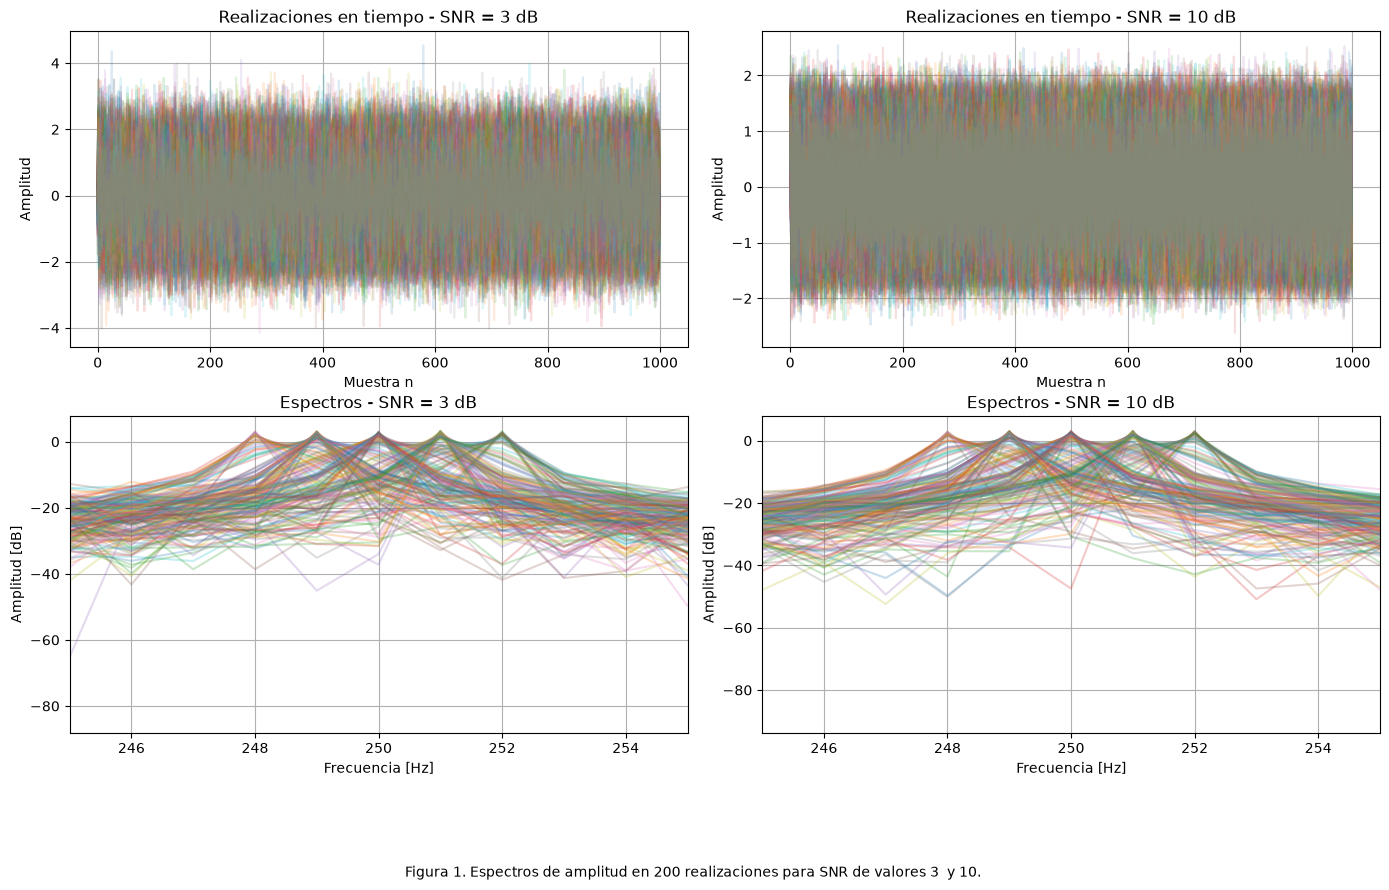

In [53]:
Pr3 = Psen / (10**(3/10))
Pr10 = Psen / (10**(10/10))

x3 = funcion_sen(A0, N, Pr3, R, fr, omega0)
x10 = funcion_sen(A0, N, Pr10, R, fr, omega0)

X3 = np.fft.fft(x3, axis=1) / N
X10 = np.fft.fft(x10, axis=1) / N

n = np.arange(N)
frec = (fs/N) * np.arange(N//2)

X3_db = 20*np.log10(2*np.abs(X3[:, :N//2]) + 1e-20)
X10_db = 20*np.log10(2*np.abs(X10[:, :N//2]) + 1e-20)

#%% Graficos
fig, ax = plt.subplots(2, 2, figsize=(14, 9))

ax[0,0].plot(n, x3.T, alpha=0.15)
ax[0,0].set_title('Realizaciones en tiempo - SNR = 3 dB')
ax[0,0].set_xlabel('Muestra n')
ax[0,0].set_ylabel('Amplitud')
ax[0,0].grid()

ax[0,1].plot(n, x10.T, alpha=0.15)
ax[0,1].set_title('Realizaciones en tiempo - SNR = 10 dB')
ax[0,1].set_xlabel('Muestra n')
ax[0,1].set_ylabel('Amplitud')
ax[0,1].grid()

ax[1,0].plot(frec, X3_db.T, alpha=0.25)
ax[1,0].set_title('Espectros - SNR = 3 dB')
ax[1,0].set_xlabel('Frecuencia [Hz]')
ax[1,0].set_ylabel('Amplitud [dB]')
ax[1,0].set_xlim(245, 255)
ax[1,0].grid()

ax[1,1].plot(frec, X10_db.T, alpha=0.25)
ax[1,1].set_title('Espectros - SNR = 10 dB')
ax[1,1].set_xlabel('Frecuencia [Hz]')
ax[1,1].set_ylabel('Amplitud [dB]')
ax[1,1].set_xlim(245, 255)
ax[1,1].grid()

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.figtext(0.5, 0.02,
            "Figura 1. Espectros de amplitud en 200 realizaciones para SNR de valores 3  y 10. ",
            ha="center")

plt.show()

Al realizar un acercamiento alrededor de la frecuencia central se observa que los máximos de las distintas realizaciones se distribuyen aproximadamente entre $248$ y $252 Hz$, de acuerdo con la variación aleatoria introducida por $f_r$. Para $SNR=3 \text{dB}$ se aprecia una mayor dispersión espectral debida al mayor nivel de ruido, mientras que para $SNR=10 \text{dB}$ los picos aparecen más definidos y con menor contribución relativa del ruido.

A continuación se definen las cuatro ventanas que serán utilizadas para el cálculo de los estimadores: rectangular, flattop, Blackman-Harris y Hann. Cada ventana modifica de manera diferente el espectro de la señal, principalmente en términos del ancho del lóbulo principal y del nivel de los lóbulos laterales. Estas diferencias tendrán influencia sobre el sesgo y la varianza obtenidos posteriormente en los estimadores de amplitud y frecuencia.

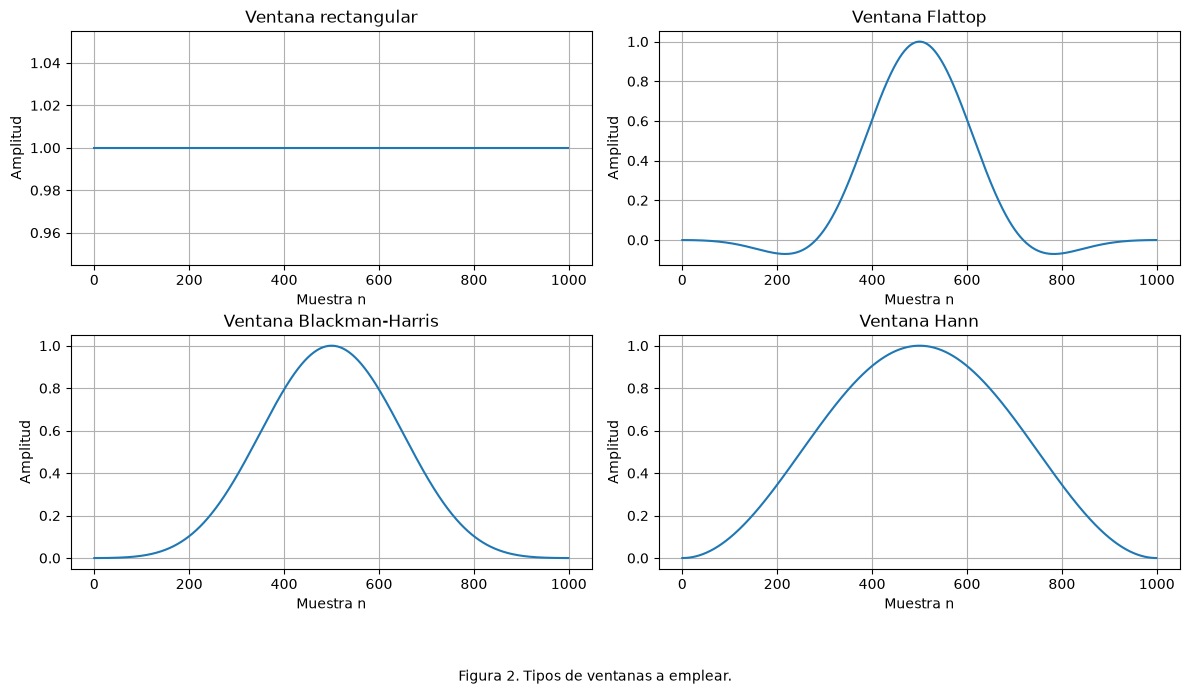

In [54]:
w_rect = np.ones(N)
w_flat = signal.windows.flattop(N, sym=False)
w_bh = signal.windows.blackmanharris(N, sym=False)
w_hann = signal.windows.hann(N, sym=False) 

n = np.arange(N)
fig, ax = plt.subplots(2, 2, figsize=(12, 7))

ax[0,0].plot(n, w_rect)
ax[0,0].set_title('Ventana rectangular')
ax[0,0].set_xlabel('Muestra n')
ax[0,0].set_ylabel('Amplitud')
ax[0,0].grid()

ax[0,1].plot(n, w_flat)
ax[0,1].set_title('Ventana Flattop')
ax[0,1].set_xlabel('Muestra n')
ax[0,1].set_ylabel('Amplitud')
ax[0,1].grid()

ax[1,0].plot(n, w_bh)
ax[1,0].set_title('Ventana Blackman-Harris')
ax[1,0].set_xlabel('Muestra n')
ax[1,0].set_ylabel('Amplitud')
ax[1,0].grid()

ax[1,1].plot(n, w_hann)
ax[1,1].set_title('Ventana Hann')
ax[1,1].set_xlabel('Muestra n')
ax[1,1].set_ylabel('Amplitud')
ax[1,1].grid()

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.figtext(0.5, 0.02,
            "Figura 2. Tipos de ventanas a emplear.",
            ha="center")
plt.show()

ventanas = {
    'Rectangular': w_rect,
    'Flattop': w_flat,
    'Blackman-Harris': w_bh,
    'Hann': w_hann
}

A partir de las realizaciones generadas se procede a estimar dos parámetros de interés de la señal senoidal: su amplitud y su frecuencia. Para ello, cada realización se multiplica por una ventana $w_i(n)$ y luego se calcula su transformada de Fourier. El estimador de amplitud se obtiene a partir del módulo del espectro evaluado en la frecuencia central $\Omega_0$
$$ 
\hat{a}_1^{\,i} = \left| X_w^{\,i}(\Omega_0) \right|
$$
mientras que el estimador de frecuencia se determina buscando la ubicación del máximo del espectro

$$
\hat{\Omega}_1^{\,i} =
\operatorname*{arg\,max}_{\Omega}
\left| X_w^{\,i}(\Omega) \right|
$$
De esta manera, para cada una de las 200 realizaciones y para cada ventana analizada se obtiene un valor estimado de amplitud y de frecuencia. Posteriormente, la distribución de estos valores permitirá comparar el comportamiento de los distintos estimadores mediante histogramas, sesgo y varianza.

In [55]:
def estimadores(xx, w, N):
    xventana = xx * w
    Xventana = np.fft.fft(xventana, axis=1)

    #estimador de amplitud
    a_estimado = 2*np.abs(Xventana[:, N//4]) / np.sum(w)

    indice = np.argmax(np.abs(Xventana[:, :N//2]), axis=1)

    #estimador de frecuancia
    omega_estimado = 2*np.pi*indice/N

    return a_estimado, omega_estimado

####  Análisis de los estimadores

Una vez definidos los estimadores de amplitud y frecuencia, se procede a evaluar su comportamiento para los dos niveles de relación señal-ruido considerados: $SNR=3\text{dB}$  y $SNR=10 \text{dB}$.

Para cada caso se utilizan las mismas 200 realizaciones de $f_r$ y se analizan las cuatro ventanas seleccionadas: rectangular, Flattop, Blackman-Harris y Hann.

#### Para  SNR= 3 dB
##### Análisis cualitativo

In [56]:
a_estimadorect3, omega_estimadorect3 = estimadores(x3, w_rect, N)
a_estimadoflat3, omega_estimadoflat3 = estimadores(x3, w_flat, N)
a_estimadobh3, omega_estimadobh3 = estimadores(x3, w_bh, N)
a_estimadohann3, omega_estimadohann3 = estimadores(x3, w_hann, N)

f_rect3 = omega_estimadorect3 * fs/(2*np.pi)
f_flat3 = omega_estimadoflat3 * fs/(2*np.pi)
f_bh3 = omega_estimadobh3 * fs/(2*np.pi)
f_hann3 = omega_estimadohann3 * fs/(2*np.pi)

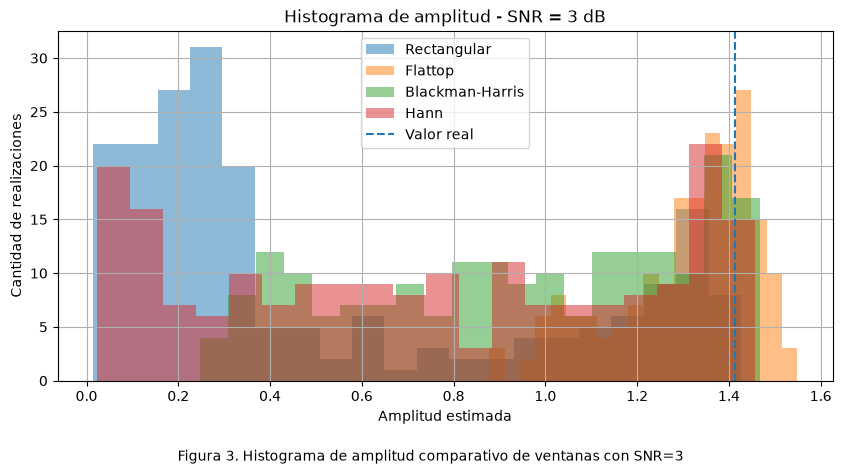

In [57]:
#Histograma de amplitud
plt.figure(figsize=(10,5))

plt.hist(a_estimadorect3, bins=20, alpha=0.5, label='Rectangular')
plt.hist(a_estimadoflat3, bins=20, alpha=0.5, label='Flattop')
plt.hist(a_estimadobh3, bins=20, alpha=0.5, label='Blackman-Harris')
plt.hist(a_estimadohann3, bins=20, alpha=0.5, label='Hann')

# Valor real de amplitud
plt.axvline(A0, linestyle='--', label='Valor real')

plt.xlabel('Amplitud estimada')
plt.ylabel('Cantidad de realizaciones')
plt.title('Histograma de amplitud - SNR = 3 dB')
plt.subplots_adjust(bottom=0.18)
plt.figtext(0.5, 0.02,
            "Figura 3. Histograma de amplitud comparativo de ventanas con SNR=3 ",
            ha="center")

plt.grid()
plt.legend()
plt.show()

Para $SNR=3\,\text{dB}$ se observa que la elección de la ventana influye de manera importante en la estimación de la amplitud. La ventana Flattop presenta la mayor concentración de valores alrededor de la amplitud real $A_0=\sqrt{2}$, lo que indica una menor sensibilidad a las pequeñas variaciones de frecuencia de las realizaciones. Esto se relaciona con la forma más plana de su lóbulo principal alrededor del máximo.

La ventana Rectangular, en cambio, presenta una distribución mucho más dispersa y una gran cantidad de estimaciones por debajo del valor real. Al poseer un lóbulo principal más angosto, el valor del espectro evaluado en $\Omega_0$ disminuye rápidamente cuando la frecuencia de la señal se aleja de dicho punto.

Las ventanas Hann y Blackman-Harris muestran un comportamiento intermedio. Sus lóbulos principales son más anchos que el de la ventana rectangular, por lo que presentan una menor sensibilidad al corrimiento de frecuencia, aunque sus estimaciones no se concentran alrededor de la amplitud real tanto como en el caso de Flattop.

En consecuencia, a partir del histograma puede anticiparse que las distintas ventanas producirán diferentes valores de sesgo y varianza en el estimador de amplitud, los cuales se calcularán posteriormente para realizar una comparación cuantitativa.

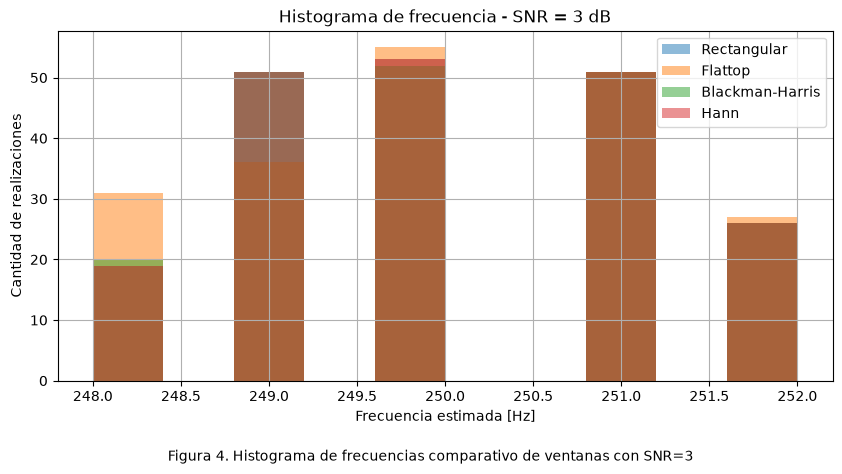

In [58]:
rango_f = (248, 252)
plt.figure(figsize=(10,5))

plt.hist(f_rect3, range=rango_f, alpha=0.5, label='Rectangular')
plt.hist(f_flat3, range=rango_f, alpha=0.5, label='Flattop')
plt.hist(f_bh3, range=rango_f, alpha=0.5, label='Blackman-Harris')
plt.hist(f_hann3, range=rango_f, alpha=0.5, label='Hann')

plt.xlabel('Frecuencia estimada [Hz]')
plt.ylabel('Cantidad de realizaciones')
plt.title('Histograma de frecuencia - SNR = 3 dB')
plt.subplots_adjust(bottom=0.18)
plt.figtext(0.5, 0.02,
            "Figura 4. Histograma de frecuencias comparativo de ventanas con SNR=3 ",
            ha="center")
plt.grid()
plt.legend()
plt.show()

Para analizar el estimador de frecuencia se representaron las 200 estimaciones obtenidas para cada ventana (ver Figura 4). Debido a que el estimador determina la frecuencia a partir del bin de máximo valor de la DFT y la resolución frecuencial es $\Delta f=1\,\text{Hz}$, las estimaciones quedan restringidas a valores discretos entre aproximadamente 248 y 252 Hz. Se observa además una gran superposición entre las cuatro ventanas, lo que indica cualitativamente un comportamiento similar del estimador de frecuencia para las ventanas analizadas.

##### Análisis cuantitativo

##### Cálculo de sesgo y varianza

Luego del análisis cualitativo de los histogramas, se calcularon el sesgo y la varianza con el objetivo de cuantificar el comportamiento de cada estimador para las distintas ventanas.

El **sesgo** permite determinar si un estimador presenta un error sistemático respecto del valor verdadero del parámetro. En términos generales, se define como:

$$
\hat{\theta}= E[(\hat{\theta}] - \theta
$$

donde $\hat{\theta}$  representa el parámetro estimado y $\theta$ su valor verdadero.

A partir de las $R=200$ realizaciones disponibles, el valor esperado del estimador se aproxima mediante el promedio muestral:

$$
E[\hat{\theta}]
\approx
\frac{1}{R}
\sum_{i=1}^{R}\hat{\theta}^{\,i}
$$

Por otro lado, la **varianza** permite cuantificar la dispersión de las estimaciones alrededor de su valor medio:

$$
Var(\hat{\theta})
\approx
\frac{1}{R}
\sum_{i=1}^{R}
\left(
\hat{\theta}^{\,i}
-
E[\hat{\theta}]
\right)^2
$$

Una varianza pequeña indica que las diferentes realizaciones producen estimaciones similares entre sí, mientras que una varianza elevada indica una mayor dispersión.

In [63]:
#Sesgo
# Rectangular
media_a_rect3 = np.mean(a_estimadorect3)
sesgo_a_rect3 = media_a_rect3 - A0
var_a_rect3 = np.var(a_estimadorect3)

# Flattop
media_a_flat3 = np.mean(a_estimadoflat3)
sesgo_a_flat3 = media_a_flat3 - A0
var_a_flat3 = np.var(a_estimadoflat3)

# Blackman-Harris
media_a_bh3 = np.mean(a_estimadobh3)
sesgo_a_bh3 = media_a_bh3 - A0
var_a_bh3 = np.var(a_estimadobh3)

# Hann
media_a_hann3 = np.mean(a_estimadohann3)
sesgo_a_hann3 = media_a_hann3 - A0
var_a_hann3 = np.var(a_estimadohann3)

tabla_amplitud_3 = pd.DataFrame({
    'Ventana': ['Rectangular', 'Flattop', 'Blackman-Harris', 'Hann'],
    'Media': [
        media_a_rect3,
        media_a_flat3,
        media_a_bh3,
        media_a_hann3
    ],
    'Sesgo': [
        sesgo_a_rect3,
        sesgo_a_flat3,
        sesgo_a_bh3,
        sesgo_a_hann3
    ],

    'Varianza': [
        var_a_rect3,
        var_a_flat3,
        var_a_bh3,
        var_a_hann3
    ]
})

tabla_amplitud_3
tabla_amplitud_3.style.set_caption(
    "Tabla 1. Análisis cuantitativo del estimador de amplitud para SNR = 3 dB"
)

,Ventana,Media,Sesgo,Varianza
0,Rectangular,0.516417,-0.897796,0.211555
1,Flattop,1.305966,-0.108247,0.022868
2,Blackman-Harris,0.946266,-0.467948,0.128721
3,Hann,0.743599,-0.670615,0.218808


A partir de los resultados obtenidos para $SNR=3\,\text{dB}$, se observa que las cuatro ventanas presentan sesgo negativo, es decir, tienden a subestimar la amplitud real $A_0=\sqrt{2}\approx1.414$. Este comportamiento está relacionado con el hecho de que el estimador evalúa el módulo de la FFT en la frecuencia central $\Omega_0$, mientras que la frecuencia real de cada realización puede encontrarse desplazada debido a la variable aleatoria $f_r$.

Sin embargo, la magnitud de este efecto cambia considerablemente según la ventana utilizada. La ventana Flattop presenta una media de $1.306$, muy próxima al valor real, junto con el menor sesgo en valor absoluto $-0.108$ y la menor varianza $0.0229$. Esto indica que no solo sus estimaciones se encuentran más próximas al valor esperado, sino que además presentan una menor dispersión entre realizaciones.

La ventana Blackman-Harris muestra un comportamiento intermedio, con una media de $0.946$, un sesgo de $-0.468$ y una varianza de $0.129$. En comparación, las ventanas Hann y Rectangular muestran una mayor tendencia a subestimar la amplitud, con medias de $0.744$ y $0.516$, respectivamente. Sus varianzas también son mayores, alrededor de $0.219$ para Hann y $0.212$ para Rectangular, indicando una mayor dispersión de las estimaciones.

En conjunto, los resultados muestran que la elección de la ventana tiene una influencia importante sobre el estimador de amplitud. En estas condiciones, la Flattop presenta el comportamiento más favorable, mientras que Blackman-Harris, Hann y Rectangular muestran progresivamente mayores diferencias respecto del valor real y una mayor variabilidad entre realizaciones. Estos resultados coinciden con lo observado previamente en el histograma.

A diferencia del estimador de amplitud, la frecuencia verdadera no permanece constante entre realizaciones debido a la variable aleatoria $f_r$. Por este motivo, el desempeño del estimador se evaluó a partir del error entre la frecuencia estimada y la frecuencia real correspondiente a cada realización. El sesgo se obtuvo como el valor medio de dicho error, mientras que su varianza permitió cuantificar la dispersión de los errores de estimación.

In [64]:
omega_real = omega0 + fr*(2*np.pi/N)
f_real = omega_real * fs/(2*np.pi)

# Rectangular
error_f_rect3 = f_rect3 - f_real
media_f_rect3 = np.mean(f_rect3)
sesgo_f_rect3 = np.mean(error_f_rect3)
var_f_rect3 = np.var(error_f_rect3)

# Flattop
error_f_flat3 = f_flat3 - f_real
media_f_flat3 = np.mean(f_flat3)
sesgo_f_flat3 = np.mean(error_f_flat3)
var_f_flat3 = np.var(error_f_flat3)

# Blackman-Harris
error_f_bh3 = f_bh3 - f_real
media_f_bh3 = np.mean(f_bh3)
sesgo_f_bh3 = np.mean(error_f_bh3)
var_f_bh3 = np.var(error_f_bh3)

# Hann
error_f_hann3 = f_hann3 - f_real
media_f_hann3 = np.mean(f_hann3)
sesgo_f_hann3 = np.mean(error_f_hann3)
var_f_hann3 = np.var(error_f_hann3)

In [66]:
tabla_frecuencia_3 = pd.DataFrame({
    
    'Ventana': [
        'Rectangular',
        'Flattop',
        'Blackman-Harris',
        'Hann'
    ],
    
    'Media [Hz]': [
        media_f_rect3,
        media_f_flat3,
        media_f_bh3,
        media_f_hann3
    ],
    
    'Sesgo [Hz]': [
        sesgo_f_rect3,
        sesgo_f_flat3,
        sesgo_f_bh3,
        sesgo_f_hann3
    ],
    
    'Varianza del error [Hz²]': [
        var_f_rect3,
        var_f_flat3,
        var_f_bh3,
        var_f_hann3
    ]
})

tabla_frecuencia_3.round(6)
tabla_frecuencia_3.style.set_caption(
    "Tabla 2. Análisis cuantitativo del estimador de frecuencia para SNR = 3 dB"
)

,Ventana,Media [Hz],Sesgo [Hz],Varianza del error [Hz²]
0,Rectangular,250.070000,0.014268,0.074938
1,Flattop,250.035000,-0.020732,0.205276
2,Blackman-Harris,250.060000,0.004268,0.076173
3,Hann,250.070000,0.014268,0.074938


Como se observa en la Tabla 2, los cuatro estimadores presentan valores medios muy próximos a la frecuencia central de $250\,\text{Hz}$, y los sesgos obtenidos son pequeños en todos los casos. Esto indica que, en promedio, las ventanas no presentan una tendencia importante a sobreestimar o subestimar la frecuencia real.

La ventana Rectangular presenta una media de $250.07\,\text{Hz}$, un sesgo de $0.0143\,\text{Hz}$ y una varianza del error de $0.0749\,\text{Hz}^2$. Estos valores muestran un comportamiento estable y un error promedio muy cercano a cero.

La ventana Flattop, que había mostrado el mejor comportamiento para la estimación de amplitud, presenta en este caso una media de $250.035\,\text{Hz}$ y un sesgo de $-0.0207\,\text{Hz}$. Aunque el sesgo continúa siendo pequeño, su varianza del error aumenta hasta $0.2053\,\text{Hz}^2$, siendo considerablemente mayor que la del resto de las ventanas. Esto indica una mayor dispersión en las estimaciones de frecuencia. Este resultado es coherente con su lóbulo principal más ancho: la característica que favorece la estimación de amplitud no resulta necesariamente favorable para determinar con precisión la ubicación del máximo espectral.

La ventana Blackman-Harris presenta una media de $250.06\,\text{Hz}$ y el menor sesgo en valor absoluto, aproximadamente $0.0043\,\text{Hz}$. Su varianza, $0.0762\,\text{Hz}^2$, es además similar a la obtenida con las ventanas Rectangular y Hann, mostrando un buen compromiso entre sesgo y dispersión.

Finalmente, la ventana Hann presenta prácticamente el mismo comportamiento que la Rectangular en este experimento, con una media de $250.07\,\text{Hz}$, un sesgo de $0.0143\,\text{Hz}$ y una varianza de $0.0749\,\text{Hz}^2$.

En conjunto, se observa que para la estimación de frecuencia las ventanas Rectangular, Hann y Blackman-Harris presentan comportamientos muy similares y varianzas reducidas, mientras que Flattop muestra una mayor dispersión. Considerando que un sesgo sistemático puede eventualmente corregirse mediante calibración, mientras que una varianza elevada implica una mayor incertidumbre entre realizaciones, en este caso resultan más favorables las ventanas con menor varianza. Esto muestra además que la ventana más conveniente depende del parámetro que se desee estimar: Flattop resultó favorable para amplitud, pero no necesariamente para frecuencia.

#### Para SNR= 10 dB
##### Análisis cualitativo

In [75]:
a_estimadorrect10, omega_estimadorrect10 = estimadores(x10, w_rect, N)
a_estimadorflat10, omega_estimadorflat10 = estimadores(x10, w_flat, N)
a_estimadorbh10, omega_estimadorbh10 = estimadores(x10, w_bh, N)
a_estimadorhann10, omega_estimadorhann10 = estimadores(x10, w_hann, N)

In [76]:
f_rect10 = omega_estimadorrect10 * fs/(2*np.pi)
f_flat10 = omega_estimadorflat10 * fs/(2*np.pi)
f_bh10 = omega_estimadorbh10 * fs/(2*np.pi)
f_hann10 = omega_estimadorhann10 * fs/(2*np.pi)

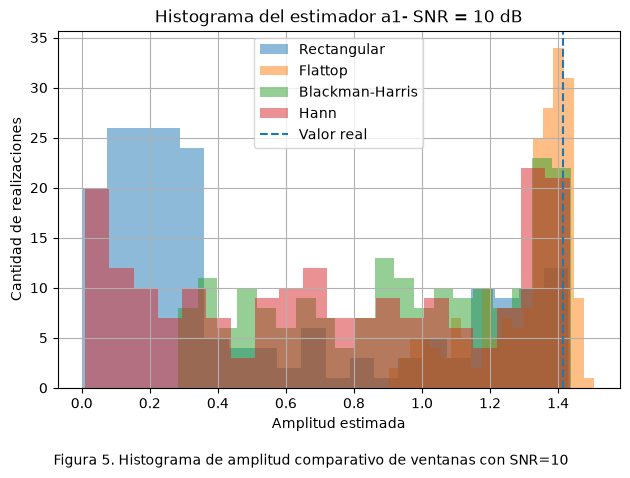

In [77]:
plt.hist(a_rect10, bins=20, alpha=0.5, label='Rectangular')
plt.hist(a_flat10, bins=20, alpha=0.5, label='Flattop')
plt.hist(a_bh10, bins=20, alpha=0.5, label='Blackman-Harris')
plt.hist(a_hann10, bins=20, alpha=0.5, label='Hann')

plt.axvline(A0, linestyle='--', label='Valor real')

plt.title('Histograma del estimador a1- SNR = 10 dB')
plt.xlabel('Amplitud estimada')
plt.ylabel('Cantidad de realizaciones')
plt.grid()
plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.figtext(0.5, 0.02,
            "Figura 5. Histograma de amplitud comparativo de ventanas con SNR=10  ",
            ha="center")
plt.legend()
plt.show()

Para $SNR=10\,\text{dB}$ se observa nuevamente una marcada dependencia del estimador de amplitud con la ventana utilizada. La ventana Flattop continúa mostrando la mayor concentración de estimaciones alrededor del valor real $A_0=\sqrt{2}$, lo que indica que resulta poco sensible al corrimiento de frecuencia introducido por $f_r$. Su distribución aparece además relativamente concentrada, anticipando un bajo sesgo y una baja varianza.

La ventana Rectangular, en cambio, mantiene una gran cantidad de estimaciones alejadas del valor real, principalmente hacia amplitudes menores. Esto ocurre porque su lóbulo principal es angosto y, cuando la frecuencia de una realización no coincide con $\Omega_0$, el valor del espectro evaluado en dicho punto disminuye considerablemente.

Las ventanas Hann y Blackman-Harris presentan nuevamente un comportamiento intermedio. Ambas muestran estimaciones distribuidas en un rango amplio, aunque una parte importante de las realizaciones se concentra cerca de la amplitud real. Al poseer lóbulos principales más anchos que la ventana rectangular, son menos sensibles a pequeñas desintonías, aunque no presentan la región superior tan plana característica de Flattop.

Al comparar cualitativamente este resultado con el obtenido para $SNR=3\,\text{dB}$, el aumento de la relación señal-ruido reduce la influencia del ruido sobre las estimaciones. Sin embargo, continúa observándose una dispersión importante en algunas ventanas, lo que indica que el error del estimador no depende únicamente del ruido, sino también del corrimiento de frecuencia respecto de $\Omega_0$ y de la respuesta espectral de cada ventana. El cálculo posterior de sesgo y varianza permitirá cuantificar estas diferencias.

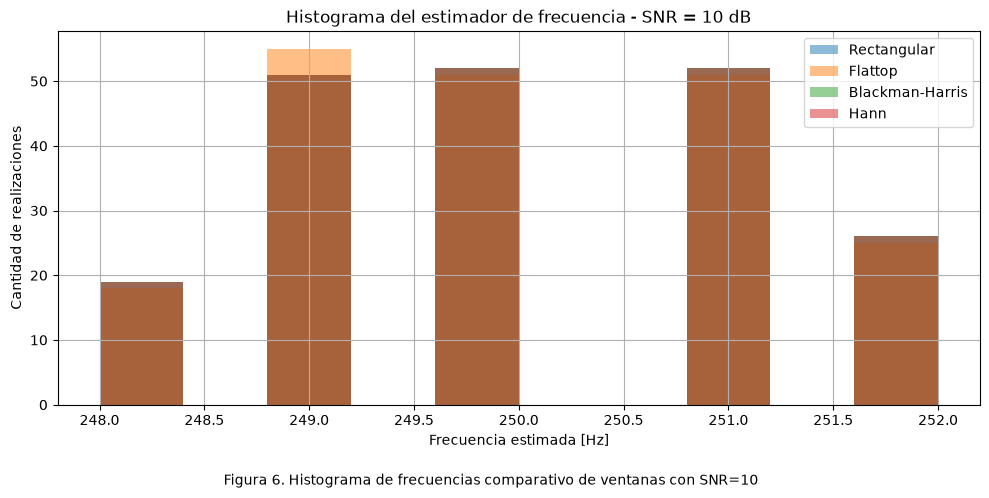

In [80]:
rango_f = (248, 252)
plt.figure(figsize=(10,5))
plt.hist(f_rect10, bins=10, range=rango_f,
         alpha=0.5, label='Rectangular')

plt.hist(f_flat10, bins=10, range=rango_f,
         alpha=0.5, label='Flattop')

plt.hist(f_bh10, bins=10, range=rango_f,
         alpha=0.5, label='Blackman-Harris')

plt.hist(f_hann10, bins=10, range=rango_f,
         alpha=0.5, label='Hann')

plt.xlabel('Frecuencia estimada [Hz]')
plt.ylabel('Cantidad de realizaciones')
plt.title('Histograma del estimador de frecuencia - SNR = 10 dB')
plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.figtext(0.5, 0.02,
            "Figura 6. Histograma de frecuencias comparativo de ventanas con SNR=10  ",
            ha="center")
plt.grid()
plt.legend()
plt.show()

Para $SNR=10\,\text{dB}$ se observa una importante superposición entre los histogramas correspondientes a las distintas ventanas. Esto indica que, al disminuir la influencia del ruido, las cuatro ventanas tienden a identificar el mismo bin de frecuencia máxima en gran parte de las realizaciones. Por este motivo, las diferencias entre ventanas resultan menos evidentes en el análisis cualitativo y será necesario recurrir al sesgo y la varianza para compararlas cuantitativamente.

##### Análisis cuantitativo

In [83]:
# Rectangular
media_a_rect10 = np.mean(a_estimadorrect10)
sesgo_a_rect10 = media_a_rect10 - A0
var_a_rect10 = np.var(a_estimadorrect10)

# Flattop
media_a_flat10 = np.mean(a_estimadorflat10)
sesgo_a_flat10 = media_a_flat10 - A0
var_a_flat10 = np.var(a_estimadorflat10)

# Blackman-Harris
media_a_bh10 = np.mean(a_estimadorbh10)
sesgo_a_bh10 = media_a_bh10 - A0
var_a_bh10 = np.var(a_estimadorbh10)

# Hann
media_a_hann10 = np.mean(a_estimadorhann10)
sesgo_a_hann10 = media_a_hann10 - A0
var_a_hann10 = np.var(a_estimadorhann10)


tabla_amplitud_10 = pd.DataFrame({

    'Ventana': [
        'Rectangular',
        'Flattop',
        'Blackman-Harris',
        'Hann'
    ],

    'Media': [
        media_a_rect10,
        media_a_flat10,
        media_a_bh10,
        media_a_hann10
    ],

    'Sesgo': [
        sesgo_a_rect10,
        sesgo_a_flat10,
        sesgo_a_bh10,
        sesgo_a_hann10
    ],

    'Varianza': [
        var_a_rect10,
        var_a_flat10,
        var_a_bh10,
        var_a_hann10
    ]
})

tabla_amplitud_10.style\
    .set_caption("Tabla 3. Análisis cuantitativo del estimador de amplitud para SNR = 10 dB")\
    .format(precision=6)

,Ventana,Media,Sesgo,Varianza
0,Rectangular,0.515023,-0.899190,0.214197
1,Flattop,1.305842,-0.108372,0.019914
2,Blackman-Harris,0.947286,-0.466927,0.127388
3,Hann,0.742079,-0.672135,0.221662


Para el estimador de amplitud con $SNR=10\,\text{dB}$, las cuatro ventanas continúan presentando sesgo negativo, por lo que en promedio subestiman la amplitud real $A_0=\sqrt{2}$. La ventana Flattop mantiene el comportamiento más favorable: presenta una media de $1.306$, un sesgo de aproximadamente $-0.108$ y la menor varianza, $0.0199$. Esto confirma que sus estimaciones permanecen concentradas cerca del valor real. Blackman-Harris muestra nuevamente un comportamiento intermedio, con media $0.947$, sesgo $-0.467$y varianza $0.127$. Las ventanas Rectangular y Hann presentan los mayores sesgos en valor absoluto y también las mayores varianzas, con valores cercanos a $0.21-0.22$.

Lo más interesante al compararlo con $SNR=3\,\text{dB}$ es que los valores cambian muy poco. Por ejemplo, la media y el sesgo de Flattop son prácticamente iguales en ambos casos, mientras que su varianza disminuye solo ligeramente. Esto indica que la dispersión del estimador de amplitud no está determinada principalmente por el ruido, sino por el hecho de que la frecuencia de cada realización puede encontrarse desplazada respecto de $\Omega_0$. La respuesta espectral de cada ventana frente a esa desintonía tiene entonces un peso importante en el resultado.

In [85]:
omega_real = omega0 + fr*(2*np.pi/N)
f_real = omega_real * fs/(2*np.pi)

# Rectangular
error_f_rect10 = f_rect10 - f_real
media_f_rect10 = np.mean(f_rect10)
sesgo_f_rect10 = np.mean(error_f_rect10)
var_f_rect10 = np.var(error_f_rect10)

# Flattop
error_f_flat10 = f_flat10 - f_real
media_f_flat10 = np.mean(f_flat10)
sesgo_f_flat10 = np.mean(error_f_flat10)
var_f_flat10 = np.var(error_f_flat10)

# Blackman-Harris
error_f_bh10 = f_bh10 - f_real
media_f_bh10 = np.mean(f_bh10)
sesgo_f_bh10 = np.mean(error_f_bh10)
var_f_bh10 = np.var(error_f_bh10)

# Hann
error_f_hann10 = f_hann10 - f_real
media_f_hann10 = np.mean(f_hann10)
sesgo_f_hann10 = np.mean(error_f_hann10)
var_f_hann10 = np.var(error_f_hann10)
tabla_frecuencia_10 = pd.DataFrame({

    'Ventana': [
        'Rectangular',
        'Flattop',
        'Blackman-Harris',
        'Hann'
    ],

    'Media [Hz]': [
        media_f_rect10,
        media_f_flat10,
        media_f_bh10,
        media_f_hann10
    ],

    'Sesgo [Hz]': [
        sesgo_f_rect10,
        sesgo_f_flat10,
        sesgo_f_bh10,
        sesgo_f_hann10
    ],

    'Varianza del error [Hz²]': [
        var_f_rect10,
        var_f_flat10,
        var_f_bh10,
        var_f_hann10
    ]
})

tabla_frecuencia_10.style\
    .set_caption("Tabla 4. Análisis cuantitativo del estimador de frecuencia para SNR = 10 dB")\
    .format(precision=6)

,Ventana,Media [Hz],Sesgo [Hz],Varianza del error [Hz²]
0,Rectangular,250.075000,0.019268,0.074437
1,Flattop,250.050000,-0.005732,0.121143
2,Blackman-Harris,250.075000,0.019268,0.074437
3,Hann,250.075000,0.019268,0.074437


Para el estimador de frecuencia las ventanas Rectangular, Blackman-Harris y Hann presentan prácticamente el mismo comportamiento en la estimación de frecuencia, con sesgos pequeños y la menor varianza del conjunto. La ventana Flattop obtiene el menor sesgo en valor absoluto, pero una varianza mayor, por lo que sus estimaciones resultan menos estables.

En este caso, si se prioriza una baja varianza, las ventanas Rectangular, Blackman-Harris y Hann resultan más convenientes para estimar la frecuencia. Esto también muestra que la ventana Flattop, aunque favorable para amplitud, no es necesariamente la mejor opción para frecuencia.

#### Conclusión

A lo largo del trabajo se analizó el efecto de distintas ventanas sobre la estimación de amplitud y frecuencia de una señal senoidal afectada por ruido, considerando 200 realizaciones y dos niveles de SNR. Los histogramas permitieron observar de manera cualitativa cómo cambia la distribución de las estimaciones según la ventana utilizada, mientras que el cálculo de sesgo y varianza permitió cuantificar esas diferencias.

Para la estimación de amplitud, la ventana Flattop presentó el mejor comportamiento, con estimaciones más concentradas alrededor del valor real y menor varianza. En cambio, para la estimación de frecuencia, las ventanas Rectangular, Hann y Blackman-Harris mostraron una menor dispersión que Flattop. Esto demuestra que no existe una única ventana óptima para todos los casos, sino que su elección depende del parámetro que se quiera estimar.

Al aumentar el SNR de 3 dB a 10 dB disminuye la influencia del ruido, aunque se mantienen diferencias asociadas a las características propias de cada ventana y al corrimiento de la frecuencia respecto de los bins de la DFT. En conjunto, los resultados muestran la importancia de analizar tanto el sesgo como la varianza al evaluar un estimador, priorizando estimaciones estables y teniendo en cuenta que un sesgo sistemático puede, en ciertos casos, corregirse mediante calibración.